# Which button?

*May 2026 · code on [github](https://github.com/4esv/red-blue-buttons). The essay and the model in one place: every number and figure is computed live from the [attached dataset](https://www.kaggle.com/datasets/axelst/which-button-world-trust).*

> Everyone in the world has to take a private vote by pressing a red or blue button. If more than 50% of people press the blue button, everyone survives. If less than 50% of people press the blue button, only people who pressed the red button survive. Which button would you press?
>
> — Tim Urban · [@waitbutwhy](https://x.com/waitbutwhy/status/2047710215265730755)

Like all good internet dilemmas, it's an obviously non-obvious problem. The less one thinks about it the sooner one arrives at an answer and the harder it is to talk one out of it. Logical people find no logical argument against red; moral people find no moral argument against blue. In the end it's really not clear the way things would go.

The first error everyone makes is in thinking that there is only one right answer to the dilemma. That is misidentifying the kind of dilemma this is. There are three outcomes: either you are saved, you save yourself or you die. So really, there are two equilibria, collaborative risk or individual salvation. We are not in a prisoner's dilemma<sup>[1](#footnotes)</sup> as there is no Faustian bargain: what we are looking at is a coordination game<sup>[2](#footnotes)</sup>. There is no us or them, we can all try to save everyone or we can all save ourselves. The more we agree the fewer die.

No lesser of an error is assuming that we all have a common goal or even the same interpretations of common goals we may coincide on. The most common goal is to maximize the survivors or to minimize the casualties, the two being sides of the same coin. Directly opposing it is the also-popular argument for dying. Both arguments hold that some deaths are justified, either those of others or their own: "some will inevitably die" and "I don't want to live in a cruel world," respectively. It's one's desire to help against one's survival sense wrapped up in whatever framework we may subscribe to.

To objectively approach something resembling an answer we have to level and examine the playing field. After ruling out the colorblind, slips, mistakes, communication, coercion and similar exits it is now possible to look at cases for both choices.

Game theory is a good place to start as it is simple and visual. For this dilemma we have two options and two scenarios which gives us four outcomes of which two are equal, so three outcomes in the end:

| | 🔴 wins | 🔵 wins |
|---:|:---:|:---:|
| **press 🔴** | You save yourself | You are saved |
| **press 🔵** | You are killed | You are saved |

One can either choose to trust that they will be saved knowing they could be killed or decide to guarantee their own survival. While any one person's blue press is insignificant, a red press is exclusively for the presser<sup>[3](#footnotes)</sup>. This choice only accounts for rational outcomes. Someone who values the choice over the outcome will press blue regardless, but this is a rare minority.

Philosophy can offer some insight as to the morality, though not all frameworks are useful. Being a coordination game, Kant's imperative<sup>[4](#footnotes)</sup> instantly renders this dilemma moot (even in a red world there are no blue-pressers to die). The hinge is placed on where we believe we lie, what we think others will press. If we simply assume that blue is twice as likely because half as much agreement is needed, we are confusing the threshold with the odds of clearing it. It may be that they're equally impossible but that one is a much narrower miss or that one is disproportionately more likely for reasons that are not immediately obvious.

Turning back to the post, there is a part that I omitted from the beginning and that was the attached poll:

**Tim's poll, final results** — 98,539 votes · [final results on x.com](https://x.com/waitbutwhy/status/2047710215265730755)

| | |
|---|---:|
| Red | 42.1% |
| Blue | 57.9% |

Netizens<sup>[5](#footnotes)</sup> generally trend blue, narrowly blue, as in the above poll from the original tweet. Note that unlike the dilemma, people are able to see prior votes (even if only by cheating) and definitely were able to discuss, extensively. This is one of the places I observed the rationalizations above<sup>[6](#footnotes)</sup>.

The nature of the problem and this unstable rhetoric along with the narrow wins across polls made me question what we would truly trend to and only made me doubt the polls more. This brought me to the idea of estimating the outcome from data or analogs to the data.

To simulate, the first step is to establish the variables at play, being trust and altruism in this case. Respectively, how much you believe in others and how much you value them. As stated previously, if altruism alone is taken into account the choice is immediately blue.

Altruism is difficult to estimate. For a lower bound I looked at organ donation rates which range from fractions of a percent for essential organs to a few percentage points for things such as blood. For the upper bound I looked at dictator game meta-studies from where I got the generous bound<sup>[7](#footnotes)</sup> of 28%<sup>[8](#footnotes)</sup>.

Trust is the key variable of the two. It varies wildly between nations and is the main driver of choice. My primary source is the World Values Survey<sup>[9](#footnotes)</sup> data corroborated with results from behavioral trust games<sup>[10](#footnotes)</sup>. The values for trust range from a low of 5% in Colombia to a high of around 74% in Denmark with the majority of countries sitting on the lower half of the distribution.

## The data

One row per surveyed nation plus a rest-of-world bucket for the ~2.7B people not individually surveyed. The column dictionary and full provenance are on the [dataset page](https://www.kaggle.com/datasets/axelst/which-button-world-trust). Loaded and sorted by trust:

In [1]:
import pandas as pd
from pathlib import Path

# The attached dataset when on Kaggle, the repo copy when run locally.
kaggle_input = sorted(Path("/kaggle/input").glob("**/countries.csv")) if Path("/kaggle/input").exists() else []
SRC = kaggle_input[0] if kaggle_input else Path("../dataset/countries.csv")

df = pd.read_csv(SRC)  # 23 surveyed countries + a rest-of-world bucket (code is empty)
df.sort_values("trust", ascending=False).reset_index(drop=True)

,code,iso2,name,trust,altruism,population
0,DNK,dk,Denmark,0.74,0.28,5800000
1,NOR,no,Norway,0.72,0.28,5400000
2,NLD,nl,Netherlands,0.66,0.28,17400000
3,CHN,cn,China,0.64,0.28,1402000000
4,SWE,se,Sweden,0.63,0.28,10300000
5,CHE,ch,Switzerland,0.59,0.28,8600000
6,FIN,fi,Finland,0.58,0.28,5500000
7,NZL,nz,New Zealand,0.57,0.28,5100000
8,AUS,au,Australia,0.48,0.28,25700000
9,GBR,gb,UK,0.46,0.28,67200000


## The model

To simulate this I ran ~7.0B agents per run based on population data matched to the countries for which trust data was available plus an estimate<sup>[11](#footnotes)</sup>. These ranged from 5.1 million agents to simulate New Zealand to over 1.4 billion agents to simulate China<sup>[12](#footnotes)</sup>.

Each agent is given a randomized trust and altruism sampled from their respective nation's ranges and is given the following rule:

$$\text{press blue if}\quad \text{trust} \times (1 + \text{altruism}) \ge 1$$

The per-country blue share has a closed form, so the notebook computes that exactly by quadrature; the ~7B-agent Monte-Carlo run that confirms it is at the end, behind a flag. Below, `blue_fraction` evaluates that closed form for one nation, `world` plays the single global game across all of them, and the `critical_*` functions locate the thresholds where an outcome flips.

In [2]:
import warnings

import numpy as np
from scipy import integrate, optimize, stats

CONCENTRATION = 7.0  # within-country spread of the trust and altruism Betas
ALTRUISM = 0.28      # dictator-game global mean (Engel 2011), a generous ceiling
LAMBDA = 1.0         # 1.0 = risk-neutral expected value; 2.25 = Kahneman-Tversky loss aversion


def beta_ab(mean, conc):
    mean = min(max(mean, 1e-6), 1 - 1e-6)
    return mean * conc, (1.0 - mean) * conc


def blue_fraction(trust_mean, altruism_mean=ALTRUISM, conc=CONCENTRATION, lam=LAMBDA):
    """Exact P[ trust >= lambda/(altruism + lambda) ], integrated over the altruism Beta."""
    a_ppf = stats.beta(*beta_ab(altruism_mean, conc)).ppf
    t_cdf = stats.beta(*beta_ab(trust_mean, conc)).cdf
    with warnings.catch_warnings():  # near-step trust Betas trip a cosmetic convergence flag
        warnings.simplefilter("ignore", integrate.IntegrationWarning)
        val, _ = integrate.quad(lambda u: 1.0 - t_cdf(lam / (a_ppf(u) + lam)), 0.0, 1.0, limit=200)
    return float(val)


def world(entries, altruism_mean=ALTRUISM, conc=CONCENTRATION, lam=LAMBDA,
          china_trust=None, trust_delta=0.0):
    """One global game over all entries: blue wins iff >50% of everyone presses blue."""
    tot_pop = tot_blue = 0.0
    per = []
    for e in entries:
        tmean = e["trust"] + trust_delta
        if china_trust is not None and e.get("code") == "CHN":
            tmean = china_trust
        q = blue_fraction(tmean, altruism_mean, conc, lam)
        per.append({"name": e["name"], "code": e.get("code"), "trust": tmean,
                    "pop": e["population"], "blue_fraction": q})
        tot_pop += e["population"]
        tot_blue += e["population"] * q
    Q = tot_blue / tot_pop
    blue_wins = Q >= 0.5
    for r in per:
        r["deaths"] = 0 if blue_wins else round(r["blue_fraction"] * r["pop"])
    return {"global_blue_fraction": Q, "blue_wins": blue_wins,
            "world_death_rate": 0.0 if blue_wins else Q, "total_pop": tot_pop, "per_country": per}


def critical_altruism(trust_mean, conc=CONCENTRATION, lam=LAMBDA):
    """Altruism mean at which this trust profile crosses 50% blue (saves itself)."""
    f = lambda a: blue_fraction(trust_mean, a, conc, lam) - 0.5
    if f(1 - 1e-4) < 0:
        return None  # even maximal altruism can't save it
    if f(1e-4) > 0:
        return 0.0
    return float(optimize.brentq(f, 1e-4, 1 - 1e-4))


def critical_trust(altruism_mean=ALTRUISM, conc=CONCENTRATION, lam=LAMBDA):
    """Trust mean at which a uniform world crosses 50% blue, at fixed altruism."""
    return float(optimize.brentq(lambda m: blue_fraction(m, altruism_mean, conc, lam) - 0.5,
                                 1e-4, 1 - 1e-4))


def world_critical_altruism(entries, conc=CONCENTRATION, lam=LAMBDA):
    """Global mean altruism at which the whole world flips to blue-wins."""
    tot = sum(e["population"] for e in entries)
    Q = lambda a: sum(e["population"] * blue_fraction(e["trust"], a, conc, lam)
                      for e in entries) / tot - 0.5
    return None if Q(1 - 1e-4) < 0 else float(optimize.brentq(Q, 1e-4, 1 - 1e-4))


entries = df.to_dict("records")
base = world(entries)
print(f"total population      {base['total_pop']:,.0f}")
print(f"global blue fraction  {base['global_blue_fraction']:.2%}")
print(f"blue wins             {base['blue_wins']}")
print(f"world death rate      {base['world_death_rate']:.2%}"
      f"  ({base['world_death_rate'] * 100_000:,.0f} per 100k)")

total population      6,991,900,000
global blue fraction  5.14%
blue wins             False
world death rate      5.14%  (5,142 per 100k)


## Results

Once every country was run their results were merged to form the world outcome that is closest to the real population and estimated behavior giving us blue presser/death toll numbers. Per one hundred thousand people:

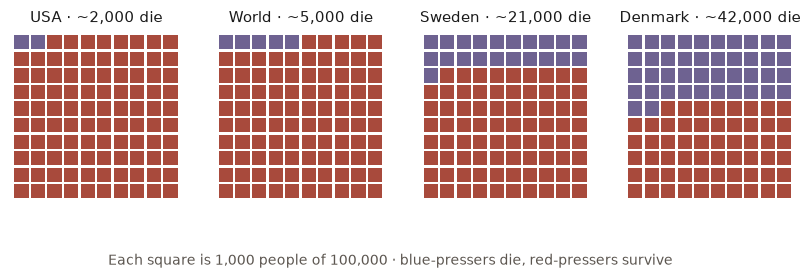

In [3]:
# The strip from the essay: each 10x10 grid is 100,000 people at 1,000 per square.
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

INK, INK_MUTE, INK_FAINT = "#1a1a1a", "#5c5650", "#bdb6a8"
GRID = "#e8dfc8"
DIE = "#6e6291"      # lavender, the blue button: blue-pressers who die
SURVIVE = "#a84a3c"  # brick, the red button: red-pressers who survive
plt.rcParams.update({"figure.dpi": 110, "text.color": INK, "axes.edgecolor": INK,
                     "axes.labelcolor": INK, "xtick.color": INK_MUTE, "ytick.color": INK_MUTE})

rate = {r["code"]: r["blue_fraction"] for r in base["per_country"] if r["code"]}
strip = [("USA", rate["USA"]), ("World", base["world_death_rate"]),
         ("Sweden", rate["SWE"]), ("Denmark", rate["DNK"])]

fig, axes = plt.subplots(1, 4, figsize=(9.2, 2.9))
for ax, (name, q) in zip(axes, strip):
    blue = round(q * 100)  # squares that die out of 100 people
    for i in range(100):
        row, col = divmod(i, 10)
        ax.add_patch(Rectangle((col, 9 - row), 0.86, 0.86,
                               color=DIE if i < blue else SURVIVE, lw=0))
    ax.set_xlim(-0.2, 10.1), ax.set_ylim(-0.2, 10.1)
    ax.set_aspect("equal"), ax.axis("off")
    ax.set_title(f"{name} · ~{round(q * 100_000, -3):,.0f} die", fontsize=10, color=INK)
fig.suptitle("Each square is 1,000 people of 100,000 · blue-pressers die, red-pressers survive",
             fontsize=9, color=INK_MUTE, y=0.02, va="bottom")
plt.show()

Nearly half of the surveyed countries are below the US for trust, and almost all of their presser counts are a rounding error<sup>[13](#footnotes)</sup>. In every simulation I could run, the most trusting nations were also the most devastated.

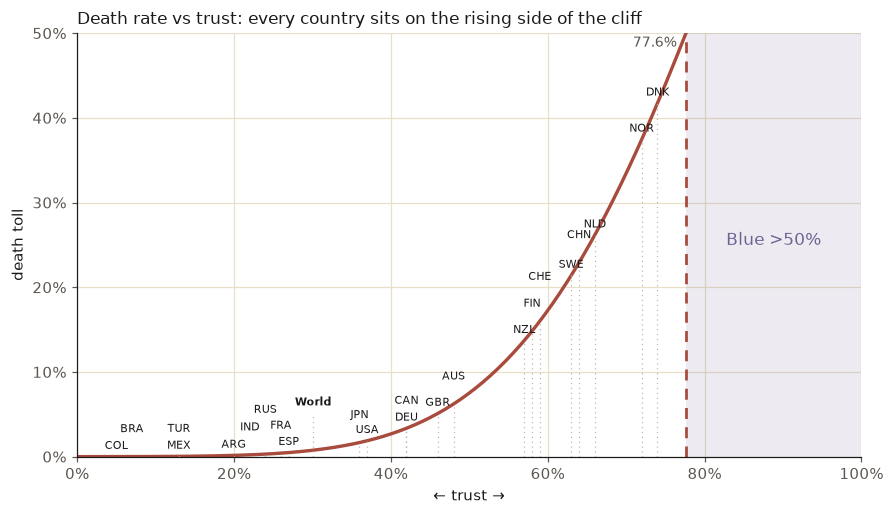

In [4]:
# Death rate of a population at every trust level: the rising side is doom,
# the cliff is where blue clears 50% and everyone lives.
ct = critical_trust()

fig, ax = plt.subplots(figsize=(9.2, 5))
ts = np.linspace(0.0, ct, 160)
ax.plot(ts, [blue_fraction(t) for t in ts], color=SURVIVE, lw=2.2)
ax.vlines(ct, 0, 0.5, color=SURVIVE, lw=1.8, ls=(0, (4, 3)))
ax.axvspan(ct, 1.0, color=DIE, alpha=0.12, lw=0)
ax.text((ct + 1) / 2, 0.25, "Blue >50%", color=DIE, ha="center", fontsize=11)
ax.annotate(f"{ct:.1%}", (ct, 0.5), textcoords="offset points", xytext=(-6, -2),
            ha="right", va="top", fontsize=9, color=INK_MUTE)

# stagger tiers so labels clear each other where the curve is flat
tier = {"BRA": 1, "TUR": 1, "IND": 1, "RUS": 2, "FRA": 1, "JPN": 1,
        "CAN": 1, "AUS": 1, "FIN": 1, "CHE": 2, "CHN": 1}
for c in df.dropna(subset=["code"]).itertuples():
    q = blue_fraction(c.trust)
    ax.vlines(c.trust, 0, q, color=INK_FAINT, lw=0.8, ls=(0, (1, 3)))
    ax.annotate(c.code, (c.trust, q), textcoords="offset points",
                xytext=(0, 5 + 11 * tier.get(c.code, 0)), ha="center", fontsize=7.5, color=INK)

w_trust = sum(e["trust"] * e["population"] for e in entries) / base["total_pop"]
ax.vlines(w_trust, 0, base["world_death_rate"], color=INK_FAINT, lw=0.8, ls=(0, (1, 3)))
ax.annotate("World", (w_trust, base["world_death_rate"]), textcoords="offset points",
            xytext=(0, 5), ha="center", fontsize=7.5, color=INK, fontweight="bold")

ax.set_xlim(0, 1), ax.set_ylim(0, 0.5)
ax.set_xlabel("← trust →"), ax.set_ylabel("death toll")
ax.xaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
ax.yaxis.set_major_formatter(lambda y, _: f"{y:.0%}")
ax.grid(color=GRID, lw=0.8), ax.set_axisbelow(True)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
ax.set_title("Death rate vs trust: every country sits on the rising side of the cliff",
             fontsize=11, color=INK, loc="left")
plt.show()

Without clearing the bar, the closer a country is to blue winning, the worse it gets. Small but high-trust countries can stand to lose nearly half their population while large low-trust countries that would dwarf them in any other category lose but a fraction of theirs. There are, of course, outliers. If we are to take the trust data at face value, China sits at the intersection of population and trust that would place its deaths north of 300 million, the bulk of the global toll: that world figure leans on China's contested 64%, and without it the world's death rate would sit below the US's. Conversely, the least trusting nation in the sample, Colombia, is also quite small and would stand to lose under 2 thousand people out of the whole nation.

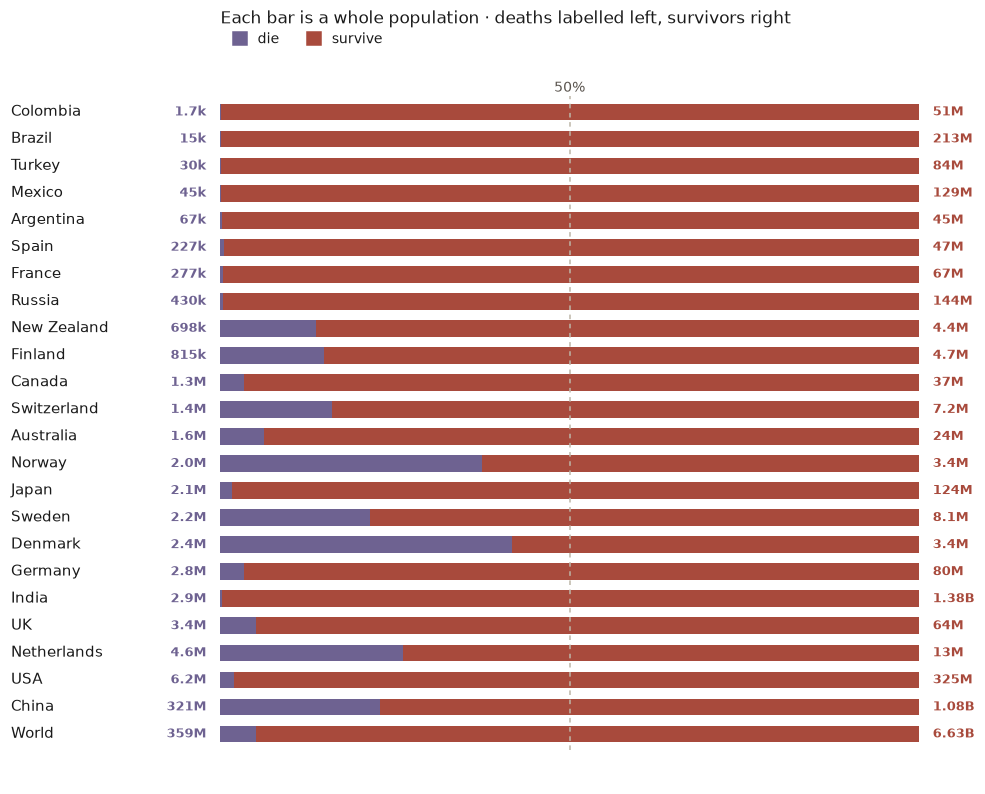

In [5]:
# One bar per country, full width = its whole population; the lavender share
# presses blue and dies, the brick share presses red and survives.
def human(x):
    for cut, div, fmt in ((1e9, 1e9, "{:.2f}B"), (1e7, 1e6, "{:.0f}M"), (1e6, 1e6, "{:.1f}M"),
                          (1e4, 1e3, "{:.0f}k"), (1e3, 1e3, "{:.1f}k")):
        if x >= cut:
            return fmt.format(x / div)
    return f"{x:.0f}"

rows = [r for r in base["per_country"] if isinstance(r["code"], str)]
rows.append({"name": "World", "blue_fraction": base["world_death_rate"],
             "pop": base["total_pop"]})
rows.sort(key=lambda r: r["blue_fraction"] * r["pop"])  # fewest deaths on top, World last

fig, ax = plt.subplots(figsize=(9.2, 8.5))
fig.subplots_adjust(left=0.24, right=0.93)
y = np.arange(len(rows))[::-1]
ax.barh(y, 1.0, color=SURVIVE, height=0.62)
ax.barh(y, [r["blue_fraction"] for r in rows], color=DIE, height=0.62)
ax.vlines(0.5, -0.6, len(rows) - 0.4, color=INK_FAINT, lw=1, ls=(0, (3, 3)))
ax.text(0.5, len(rows) - 0.25, "50%", ha="center", fontsize=9, color=INK_MUTE)
tf = ax.get_yaxis_transform()  # x in axes fraction, y in data coords
for yi, r in zip(y, rows):
    deaths = r["blue_fraction"] * r["pop"]
    ax.text(-0.30, yi, r["name"], transform=tf, ha="left", va="center",
            fontsize=9.5, color=INK)
    ax.text(-0.02, yi, human(deaths), transform=tf, ha="right", va="center",
            fontsize=8.5, color=DIE, fontweight="bold")
    ax.text(1.02, yi, human(r["pop"] - deaths), transform=tf, ha="left", va="center",
            fontsize=8.5, color=SURVIVE, fontweight="bold")
ax.set_yticks([])
ax.set_xlim(0, 1), ax.set_xticks([])
for s in ("top", "right", "bottom", "left"):
    ax.spines[s].set_visible(False)
ax.tick_params(left=False)
ax.legend(handles=[Rectangle((0, 0), 1, 1, color=DIE), Rectangle((0, 0), 1, 1, color=SURVIVE)],
          labels=["die", "survive"], loc="upper left", bbox_to_anchor=(0, 1.06),
          ncols=2, frameon=False, fontsize=9, handlelength=1, handleheight=1)
ax.set_title("Each bar is a whole population · deaths labelled left, survivors right",
             fontsize=11, color=INK, loc="left", pad=26)
plt.show()

The full ledger, with the altruism each country would need to save itself:

In [6]:
ledger = pd.DataFrame([{
    "country": r["name"], "trust": r["trust"], "population": r["pop"],
    "blue = death rate": f"{r['blue_fraction']:.2%}",
    "per 100k": round(r["blue_fraction"] * 100_000),
    "deaths": r["deaths"],
    "altruism to self-save": (lambda a: "impossible" if a is None else f"{a:.2f}")(
        critical_altruism(r["trust"])),
} for r in sorted(base["per_country"], key=lambda x: -x["blue_fraction"])])
ledger

,country,trust,population,blue = death rate,per 100k,deaths,altruism to self-save
0,Denmark,0.74,5800000,41.73%,41733,2420540,0.34
1,Norway,0.72,5400000,37.47%,37469,2023344,0.38
2,Netherlands,0.66,17400000,26.15%,26153,4550626,0.51
3,China,0.64,1402000000,22.91%,22912,321230823,0.55
4,Sweden,0.63,10300000,21.39%,21394,2203617,0.58
5,Switzerland,0.59,8600000,16.00%,15998,1375825,0.69
6,Finland,0.58,5500000,14.81%,14814,814770,0.72
7,New Zealand,0.57,5100000,13.69%,13694,698389,0.75
8,Australia,0.48,25700000,6.21%,6214,1597005,impossible
9,UK,0.46,67200000,5.10%,5102,3428570,impossible


Half-coordinated optimism kills far more people than selfishness ever could<sup>[14](#footnotes)</sup>. Getting half of earth on board is not more likely than getting most people to save themselves, but the thought that it may be could doom nearly half the people of certain nations.

In the dilemma where nobody can communicate, if you're undecided press red. There's no guarantee otherwise. But in our world, where communication does very much happen, blue is the right choice (as we saw in the poll).

## Sensitivity

How much the headline moves when the assumptions do. The thresholds first:

In [7]:
print(f"a uniform world needs trust >= {critical_trust():.1%} to survive (at a={ALTRUISM})")
wca = world_critical_altruism(entries)
print(f"the real heterogeneous world flips blue at mean altruism"
      f" {'— never; even a=1 fails' if wca is None else f'>= {wca:.2f}'}")
dk = critical_altruism(0.74)
print(f"Denmark (trust 0.74) self-saves only if altruism >= {dk:.2f} (vs the assumed {ALTRUISM})")

a uniform world needs trust >= 77.6% to survive (at a=0.28)
the real heterogeneous world flips blue at mean altruism — never; even a=1 fails
Denmark (trust 0.74) self-saves only if altruism >= 0.34 (vs the assumed 0.28)


In [8]:
sweeps = [("China's trust (contested; 1.4B people)", "china_trust", (0.64, 0.45, 0.30, 0.20)),
          ("altruism mean (0.28 is a weak proxy for 'die for a stranger')", "altruism_mean",
           (0.10, 0.20, 0.28, 0.40, 0.50, 0.70, 1.00)),
          ("loss aversion lambda (2.25 = Kahneman-Tversky)", "lam", (1.0, 1.5, 2.25)),
          ("Beta concentration (within-country spread)", "conc", (4.0, 5.0, 6.0, 7.0, 8.0, 10.0)),
          ("survey error on trust (shift every country)", "trust_delta", (-0.03, 0.0, 0.03))]
pd.DataFrame([{"parameter": label, "value": v,
               "world death rate": f"{world(entries, **{kw: v})['world_death_rate']:.2%}"}
              for label, kw, vals in sweeps for v in vals])

,parameter,value,world death rate
0,China's trust (contested; 1.4B people),0.64,5.14%
1,China's trust (contested; 1.4B people),0.45,1.47%
2,China's trust (contested; 1.4B people),0.30,0.70%
3,China's trust (contested; 1.4B people),0.20,0.58%
4,altruism mean (0.28 is a weak proxy for 'die f...,0.10,1.29%
5,altruism mean (0.28 is a weak proxy for 'die f...,0.20,3.27%
6,altruism mean (0.28 is a weak proxy for 'die f...,0.28,5.14%
7,altruism mean (0.28 is a weak proxy for 'die f...,0.40,8.13%
8,altruism mean (0.28 is a weak proxy for 'die f...,0.50,10.63%
9,altruism mean (0.28 is a weak proxy for 'die f...,0.70,15.35%


## Confirmation at real scale

The quadrature is the result; the simulation exists to confirm it. Set `CONFIRM = True` to redraw every one of the ~7 billion agents (several minutes of runtime). The checked-in run matched the closed form to 0.0004 pp.

In [9]:
CONFIRM = False  # True reruns the full ~7e9-agent Monte-Carlo

def confirm_real_scale(entries, chunk=25_000_000, seed=42):
    rng = np.random.default_rng(seed)
    aa, ab = beta_ab(ALTRUISM, CONCENTRATION)
    tot_pop = tot_blue = 0
    for e in entries:
        ta, tb = beta_ab(e["trust"], CONCENTRATION)
        remaining, blue = int(e["population"]), np.int64(0)
        while remaining > 0:
            n = min(chunk, remaining)
            a = rng.beta(aa, ab, size=n)
            t = rng.beta(ta, tb, size=n)
            blue += (t >= (LAMBDA / (a + LAMBDA))).sum(dtype=np.int64)
            remaining -= n
        tot_pop += int(e["population"])
        tot_blue += int(blue)
    return tot_pop, tot_blue / tot_pop

if CONFIRM:
    agents, Q = confirm_real_scale(entries)
    print(f"agents simulated      {agents:,}")
    print(f"global blue fraction  {Q:.4%}  (quadrature said {base['global_blue_fraction']:.4%})")
    print(f"delta                 {abs(Q - base['global_blue_fraction']) * 100:.4f} pp")
else:
    print("skipped — last full run: 6,991,900,000 agents, delta 0.0004 pp vs quadrature")

skipped — last full run: 6,991,900,000 agents, delta 0.0004 pp vs quadrature


## Footnotes

1. A prisoner's dilemma has a single dominant move, defect, no matter what the other player does, and its one equilibrium is bad for everyone. This is not that: pressing red keeps you alive whether blue wins or loses, so red is merely the safe play, and the only pull toward blue is the value you place on others. [SEP, "Prisoner's Dilemma"](https://plato.stanford.edu/entries/prisoner-dilemma/).
2. A coordination game: the two outcomes that save everyone, all-red and all-blue, are equally good, but pressing red keeps you alive either way, so landing on the all-blue one takes trust rather than logic. [SEP, "Game Theory"](https://plato.stanford.edu/entries/game-theory/).
3. Survivor guilt, the weight of having lived where others did not, was a listed feature of post-traumatic stress in the 1980 DSM-III and dropped from the criteria by 1987. [On its diagnostic history](https://pmc.ncbi.nlm.nih.gov/articles/PMC9527673/).
4. Kant's Formula of Universal Law, from the 1785 *Groundwork*: act only on a maxim you could at the same time will to be a universal law. A world where everyone presses red, or everyone presses blue, leaves no one to die; the deaths come only from a split world, which no shared maxim produces, so the rule is neutral between the two safe options. [SEP, "Kant's Moral Philosophy"](https://plato.stanford.edu/entries/kant-moral/).
5. A netizen is a citizen of the internet.
6. Cleaned up from the comment sections, with the profanity and the typos taken out and the reasoning left in.
7. The high end on purpose, to give blue the best chance.
8. Engel's meta-study of dictator games (129 papers, 41,433 observations) puts average giving at 28% of the pot. [Engel, 2011](https://homepage.coll.mpg.de/pdf_dat/2010_07online.pdf). The mean flatters: a third of dictators give nothing. Costly altruism toward strangers runs far lower; non-directed kidney donors, who give a kidney to someone they will never meet, numbered 387 in the entire United States in 2019. [OPTN data, Jan et al. 2022](https://pmc.ncbi.nlm.nih.gov/articles/PMC9171626/).
9. World Values Survey, Wave 7 (2017-2022), Question Q57: *"Generally speaking, would you say that most people can be trusted or that you need to be very careful in dealing with people?"* [worldvaluessurvey.org](https://www.worldvaluessurvey.org/WVSDocumentationWV7.jsp). Denmark itself is not in Wave 7; its figure comes from the [European Values Study 2017](https://europeanvaluesstudy.eu/methodology-data-documentation/survey-2017/full-release-evs2017/), merged into the same series.
10. The corroboration, three different instruments: the Integrated Values Surveys put Denmark at 73.9% (2022, via [Our World in Data](https://ourworldindata.org/trust)); the [OECD's 2023 Trust Survey](https://www.oecd.org/content/dam/oecd/en/publications/reports/2024/06/oecd-survey-on-drivers-of-trust-in-public-institutions-2024-results-country-notes_33192204/denmark_c2330f34/ac5b6973-en.pdf) at 75%; and a rescaled [European Social Survey](https://ourworldindata.org/grapher/interpersonal-trust-measured-in-different-surveys) reading at 77.3% (2018). Behaviorally, in the trust game (the money you hand over is multiplied before the other player decides what to return) senders part with about half across 162 studies. [Johnson & Mislin, 2011](https://ideas.repec.org/a/eee/joepsy/v32y2011i5p865-889.html).
11. Trust and altruism are drawn from Beta distributions around each nation's mean (concentration 7); an agent presses blue when trust × (1 + altruism) ≥ 1, the risk-neutral expected-value rule at altruism a = 0.28. Blue wins only if more than half of everyone presses it, and across every country and the world it never did. The death rate is a closed-form result, confirmed by a Monte-Carlo run at the real population, about 7 billion agents. Code and parameters are in the repository above.
12. This could have been done with a normalized hundred thousand per country, or estimated as an integral, but what's the fun in that?
13. Under the model's preset conditions: no errors, no communication, and no coercion.
14. That is, if you don't argue that the failure is the fault of the majority, and thus always a problem with selfishness.